In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()

if (current_dir / "cartpole.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "cartpole.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find cartpole.py in the current directory or its parent."
    )

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [DATA_DIR, FIGURE_DIR, NOTEBOOK_DIR, REPORT_DIR, SRC_DIR]:
    folder.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure dir:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning
Figure dir: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures


In [4]:
from cartpole import CartPole, remap_angle

RAW_STATE_NAMES = ["x", "x_dot", "theta", "theta_dot"]

FEATURE_NAMES = [
    "x",
    "x_dot",
    "sin(theta)",
    "cos(theta)",
    "theta_dot",
]

DELTA_NAMES = [
    "Delta x",
    "Delta x_dot",
    "Delta theta",
    "Delta theta_dot",
]

STATE_LABELS = [
    "cart position x",
    "cart velocity x_dot",
    "pole angle theta",
    "pole angular velocity theta_dot",
]


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)
    return path


def mse(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)


def mse_per_dimension(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2, axis=0)

In [6]:
dataset_path = DATA_DIR / "task1_3_linear_model_dataset_500.npz"

data = np.load(dataset_path)

X_raw = data["X_initial"]
Y = data["Delta_X"]

print("Loaded dataset:", dataset_path)
print("X_raw shape:", X_raw.shape)
print("Y shape:", Y.shape)

Loaded dataset: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task1_3_linear_model_dataset_500.npz
X_raw shape: (500, 4)
Y shape: (500, 4)


In [8]:
def make_sincos_state_features(X_raw):
    """
    Convert raw CartPole states [x, x_dot, theta, theta_dot]
    into features [x, x_dot, sin(theta), cos(theta), theta_dot].

    X_raw shape: (N, 4) or (4,)
    returns: Z shape (N, 5)
    """
    X_raw = np.asarray(X_raw)

    if X_raw.ndim == 1:
        X_raw = X_raw[None, :]

    x = X_raw[:, 0]
    x_dot = X_raw[:, 1]
    theta = X_raw[:, 2]
    theta_dot = X_raw[:, 3]

    Z = np.column_stack([
        x,
        x_dot,
        np.sin(theta),
        np.cos(theta),
        theta_dot,
    ])

    return Z

In [10]:
def make_sincos_state_features(X_raw):
    """
    Convert raw CartPole states [x, x_dot, theta, theta_dot]
    into features [x, x_dot, sin(theta), cos(theta), theta_dot].

    X_raw shape: (N, 4) or (4,)
    returns: Z shape (N, 5)
    """
    X_raw = np.asarray(X_raw)

    if X_raw.ndim == 1:
        X_raw = X_raw[None, :]

    x = X_raw[:, 0]
    x_dot = X_raw[:, 1]
    theta = X_raw[:, 2]
    theta_dot = X_raw[:, 3]

    Z = np.column_stack([
        x,
        x_dot,
        np.sin(theta),
        np.cos(theta),
        theta_dot,
    ])

    return Z

In [12]:
Z_demo = make_sincos_state_features(X_raw[:5])

print("X_raw[:5] shape:", X_raw[:5].shape)
print("Z_demo shape:", Z_demo.shape)
print("First 5 feature rows:")
print(Z_demo)

X_raw[:5] shape: (5, 4)
Z_demo shape: (5, 5)
First 5 feature rows:
[[ 0.11821625 -1.56792885  0.26282141  0.9648445   3.21800666]
 [ 4.50463696 -9.48865802  0.20042743 -0.97970855 11.38004362]
 [-3.55840387 -6.64037058  0.95991141  0.28030356  0.48689698]
 [ 4.48649447  4.98921652  0.28034966  0.95989795  3.37769327]
 [-1.88168548 -8.31990464 -0.2262602   0.9740669   6.45491681]]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_3_raw_angle_vs_sincos_features.png


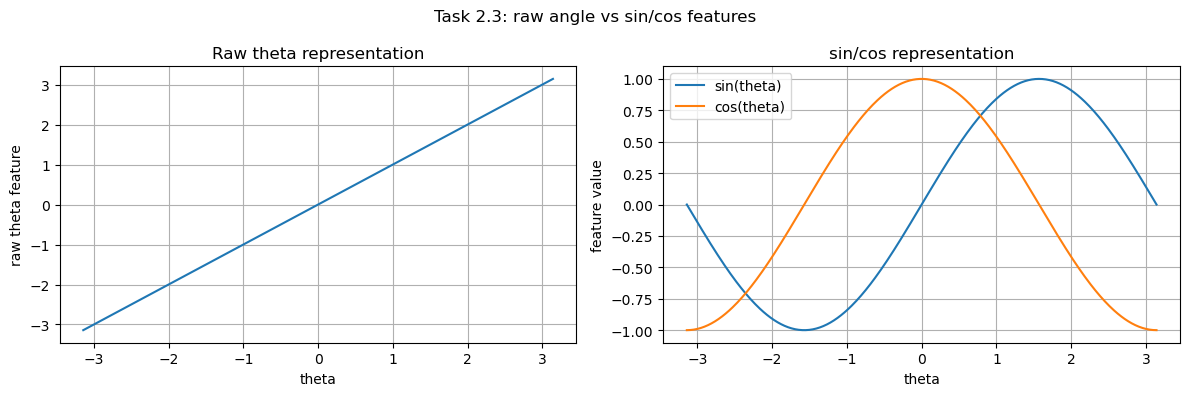

In [14]:
theta_values = np.linspace(-np.pi, np.pi, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(theta_values, theta_values)
axes[0].set_xlabel("theta")
axes[0].set_ylabel("raw theta feature")
axes[0].set_title("Raw theta representation")
axes[0].grid(True)

axes[1].plot(theta_values, np.sin(theta_values), label="sin(theta)")
axes[1].plot(theta_values, np.cos(theta_values), label="cos(theta)")
axes[1].set_xlabel("theta")
axes[1].set_ylabel("feature value")
axes[1].set_title("sin/cos representation")
axes[1].legend()
axes[1].grid(True)

fig.suptitle("Task 2.3: raw angle vs sin/cos features")
fig.tight_layout()

save_figure(fig, "sf3_task2_3_raw_angle_vs_sincos_features.png")
plt.show()

In [16]:
N = X_raw.shape[0]

rng = np.random.default_rng(123)
indices = rng.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train_raw = X_raw[train_idx]
Y_train = Y[train_idx]

X_val_raw = X_raw[val_idx]
Y_val = Y[val_idx]

X_test_raw = X_raw[test_idx]
Y_test = Y[test_idx]

Z_train = make_sincos_state_features(X_train_raw)
Z_val = make_sincos_state_features(X_val_raw)
Z_test = make_sincos_state_features(X_test_raw)

print("X_train_raw shape:", X_train_raw.shape)
print("Z_train shape:", Z_train.shape)
print("Y_train shape:", Y_train.shape)

print("Z_val shape:", Z_val.shape)
print("Y_val shape:", Y_val.shape)

print("Z_test shape:", Z_test.shape)
print("Y_test shape:", Y_test.shape)

X_train_raw shape: (300, 4)
Z_train shape: (300, 5)
Y_train shape: (300, 4)
Z_val shape: (100, 5)
Y_val shape: (100, 4)
Z_test shape: (100, 5)
Y_test shape: (100, 4)


In [18]:
def make_linear_design_from_features(Z, use_intercept=True):
    Z = np.asarray(Z)

    if use_intercept:
        ones = np.ones(Z.shape[0])
        Phi = np.column_stack([Z, ones])
    else:
        Phi = Z.copy()

    return Phi

In [20]:
Phi_train_sincos = make_linear_design_from_features(Z_train, use_intercept=True)
Phi_val_sincos = make_linear_design_from_features(Z_val, use_intercept=True)
Phi_test_sincos = make_linear_design_from_features(Z_test, use_intercept=True)

W_sincos_linear, residuals, rank, singular_values = np.linalg.lstsq(
    Phi_train_sincos,
    Y_train,
    rcond=None,
)

Y_pred_train_linear_sincos = Phi_train_sincos @ W_sincos_linear
Y_pred_val_linear_sincos = Phi_val_sincos @ W_sincos_linear
Y_pred_test_linear_sincos = Phi_test_sincos @ W_sincos_linear

linear_sincos_train_mse = mse(Y_train, Y_pred_train_linear_sincos)
linear_sincos_val_mse = mse(Y_val, Y_pred_val_linear_sincos)
linear_sincos_test_mse = mse(Y_test, Y_pred_test_linear_sincos)

linear_sincos_test_mse_dim = mse_per_dimension(Y_test, Y_pred_test_linear_sincos)

print("W_sincos_linear shape:", W_sincos_linear.shape)

print("\nLinear sin/cos MSE:")
print("Train:", linear_sincos_train_mse)
print("Validation:", linear_sincos_val_mse)
print("Test:", linear_sincos_test_mse)

print("\nTest MSE per dimension:")
print(linear_sincos_test_mse_dim)

W_sincos_linear shape: (6, 4)

Linear sin/cos MSE:
Train: 0.594848683348215
Validation: 0.7367931259851125
Test: 0.6488879488820435

Test MSE per dimension:
[9.34060298e-04 4.01031741e-01 5.17630114e-03 2.18840969e+00]


In [22]:
def make_raw_linear_design(X_raw, use_intercept=True):
    X_raw = np.asarray(X_raw)

    if use_intercept:
        ones = np.ones(X_raw.shape[0])
        Phi = np.column_stack([X_raw, ones])
    else:
        Phi = X_raw.copy()

    return Phi


Phi_train_raw = make_raw_linear_design(X_train_raw, use_intercept=True)
Phi_val_raw = make_raw_linear_design(X_val_raw, use_intercept=True)
Phi_test_raw = make_raw_linear_design(X_test_raw, use_intercept=True)

W_raw_linear, residuals, rank, singular_values = np.linalg.lstsq(
    Phi_train_raw,
    Y_train,
    rcond=None,
)

Y_pred_train_linear_raw = Phi_train_raw @ W_raw_linear
Y_pred_val_linear_raw = Phi_val_raw @ W_raw_linear
Y_pred_test_linear_raw = Phi_test_raw @ W_raw_linear

linear_raw_train_mse = mse(Y_train, Y_pred_train_linear_raw)
linear_raw_val_mse = mse(Y_val, Y_pred_val_linear_raw)
linear_raw_test_mse = mse(Y_test, Y_pred_test_linear_raw)

print("Raw linear MSE:")
print("Train:", linear_raw_train_mse)
print("Validation:", linear_raw_val_mse)
print("Test:", linear_raw_test_mse)

print("\nSin/cos linear MSE:")
print("Train:", linear_sincos_train_mse)
print("Validation:", linear_sincos_val_mse)
print("Test:", linear_sincos_test_mse)

Raw linear MSE:
Train: 0.9747744539546475
Validation: 1.011432450287362
Test: 1.291384860465522

Sin/cos linear MSE:
Train: 0.594848683348215
Validation: 0.7367931259851125
Test: 0.6488879488820435


In [24]:
def gaussian_kernel_matrix_features(Z_a, Z_b, length_scales):
    """
    Standard Gaussian kernel on sin/cos feature vectors.

    Z_a shape: (N, 5)
    Z_b shape: (M, 5)
    length_scales shape: (5,)
    """
    Z_a = np.asarray(Z_a)
    Z_b = np.asarray(Z_b)
    length_scales = np.asarray(length_scales)

    diff = Z_a[:, None, :] - Z_b[None, :, :]
    scaled_squared = diff ** 2 / (2.0 * length_scales[None, None, :] ** 2)

    K = np.exp(-np.sum(scaled_squared, axis=2))

    return K

In [26]:
def choose_centres(Z_train, M, seed=0):
    rng = np.random.default_rng(seed)

    if M > Z_train.shape[0]:
        raise ValueError("M cannot be larger than number of training points.")

    centre_indices = rng.choice(Z_train.shape[0], size=M, replace=False)
    centres = Z_train[centre_indices]

    return centres, centre_indices


def fit_kernel_model_features(Z_train, Y_train, centres, length_scales, reg_strength):
    K_NM = gaussian_kernel_matrix_features(
        Z_train,
        centres,
        length_scales,
    )

    K_MN = K_NM.T

    K_MM = gaussian_kernel_matrix_features(
        centres,
        centres,
        length_scales,
    )

    A = K_MN @ K_NM + reg_strength * K_MM
    rhs = K_MN @ Y_train

    alpha = np.linalg.solve(A, rhs)

    return alpha


def predict_kernel_model_features(Z_query, centres, length_scales, alpha):
    K_query = gaussian_kernel_matrix_features(
        Z_query,
        centres,
        length_scales,
    )

    Y_pred = K_query @ alpha

    return Y_pred

In [28]:
M = 80
reg_strength = 1e-3

centres_sincos, centre_indices = choose_centres(Z_train, M, seed=456)

length_scales_sincos = np.std(Z_train, axis=0)
length_scales_sincos = np.maximum(length_scales_sincos, 1e-6)

alpha_sincos = fit_kernel_model_features(
    Z_train=Z_train,
    Y_train=Y_train,
    centres=centres_sincos,
    length_scales=length_scales_sincos,
    reg_strength=reg_strength,
)

Y_pred_train_kernel_sincos = predict_kernel_model_features(
    Z_train,
    centres_sincos,
    length_scales_sincos,
    alpha_sincos,
)

Y_pred_val_kernel_sincos = predict_kernel_model_features(
    Z_val,
    centres_sincos,
    length_scales_sincos,
    alpha_sincos,
)

Y_pred_test_kernel_sincos = predict_kernel_model_features(
    Z_test,
    centres_sincos,
    length_scales_sincos,
    alpha_sincos,
)

kernel_sincos_train_mse = mse(Y_train, Y_pred_train_kernel_sincos)
kernel_sincos_val_mse = mse(Y_val, Y_pred_val_kernel_sincos)
kernel_sincos_test_mse = mse(Y_test, Y_pred_test_kernel_sincos)

kernel_sincos_test_mse_dim = mse_per_dimension(Y_test, Y_pred_test_kernel_sincos)

print("centres_sincos shape:", centres_sincos.shape)
print("alpha_sincos shape:", alpha_sincos.shape)
print("length_scales_sincos:", length_scales_sincos)

print("\nKernel sin/cos MSE:")
print("Train:", kernel_sincos_train_mse)
print("Validation:", kernel_sincos_val_mse)
print("Test:", kernel_sincos_test_mse)

print("\nTest MSE per dimension:")
print(kernel_sincos_test_mse_dim)

centres_sincos shape: (80, 5)
alpha_sincos shape: (80, 4)
length_scales_sincos: [2.83338634 5.97845233 0.70161687 0.7125383  8.33679617]

Kernel sin/cos MSE:
Train: 0.13951232366044986
Validation: 0.2583870426442834
Test: 0.2752646090687738

Test MSE per dimension:
[0.0356891  0.12744637 0.04860492 0.88931805]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_3_model_mse_comparison.png


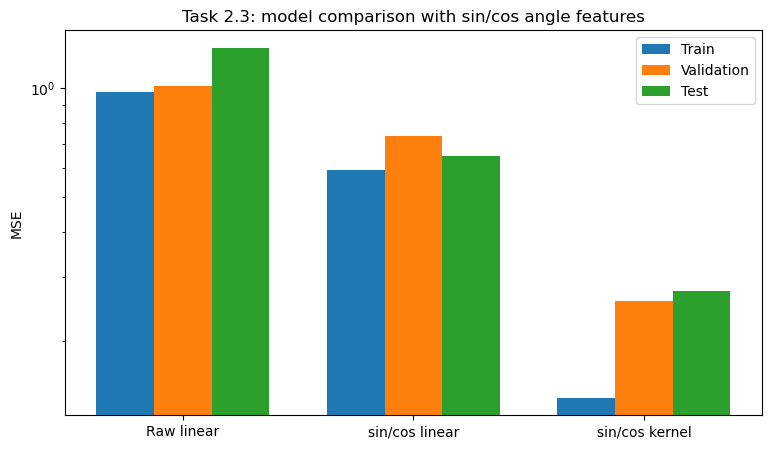

In [30]:
model_names = [
    "Raw linear",
    "sin/cos linear",
    "sin/cos kernel",
]

train_values = [
    linear_raw_train_mse,
    linear_sincos_train_mse,
    kernel_sincos_train_mse,
]

val_values = [
    linear_raw_val_mse,
    linear_sincos_val_mse,
    kernel_sincos_val_mse,
]

test_values = [
    linear_raw_test_mse,
    linear_sincos_test_mse,
    kernel_sincos_test_mse,
]

positions = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(positions - width, train_values, width, label="Train")
ax.bar(positions, val_values, width, label="Validation")
ax.bar(positions + width, test_values, width, label="Test")

ax.set_xticks(positions)
ax.set_xticklabels(model_names)
ax.set_ylabel("MSE")
ax.set_title("Task 2.3: model comparison with sin/cos angle features")
ax.set_yscale("log")
ax.legend()

save_figure(fig, "sf3_task2_3_model_mse_comparison.png")
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_3_sincos_kernel_prediction_vs_truth.png


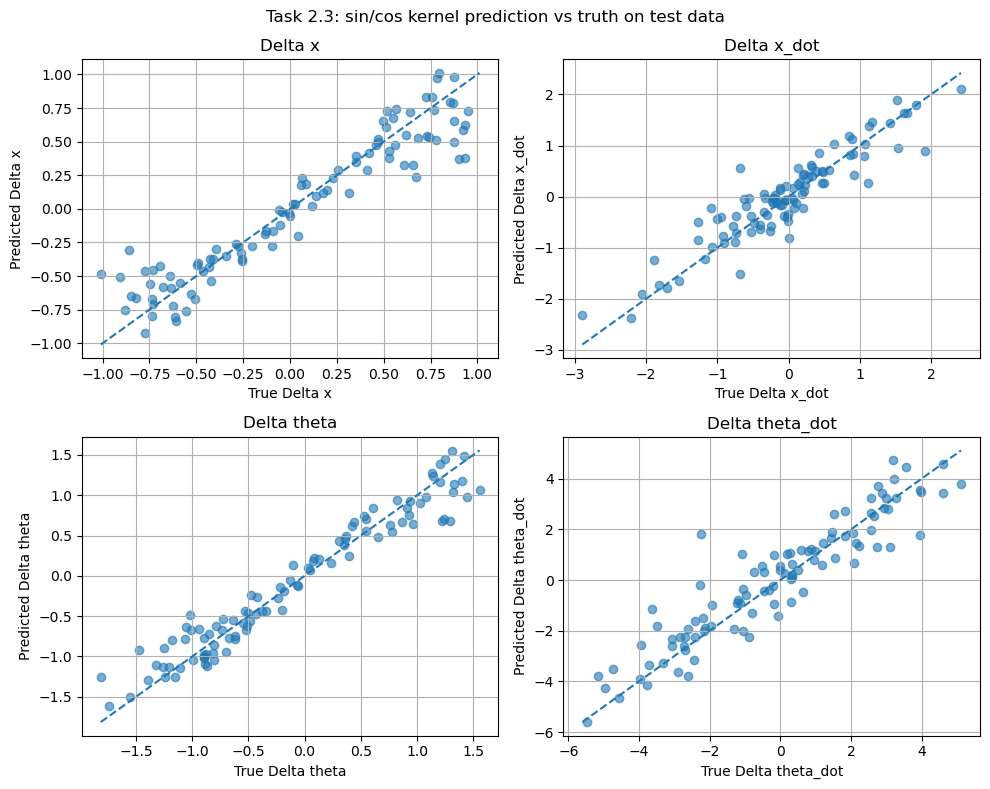

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for dim in range(4):
    ax = axes[dim]

    y_true = Y_test[:, dim]
    y_pred = Y_pred_test_kernel_sincos[:, dim]

    ax.scatter(y_true, y_pred, alpha=0.6)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        label="perfect prediction",
    )

    ax.set_xlabel(f"True {DELTA_NAMES[dim]}")
    ax.set_ylabel(f"Predicted {DELTA_NAMES[dim]}")
    ax.set_title(DELTA_NAMES[dim])
    ax.grid(True)

fig.suptitle("Task 2.3: sin/cos kernel prediction vs truth on test data")
fig.tight_layout()

save_figure(fig, "sf3_task2_3_sincos_kernel_prediction_vs_truth.png")
plt.show()

In [34]:
def one_step_zero_force(initial_state):
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    x0 = system.getState()
    system.performAction(0.0)
    x_next = system.getState()

    delta_x = x_next - x0

    return x0, x_next, delta_x


base_state = np.array([0.0, 1.0, 0.0, 2.0])
theta_scan = np.linspace(-np.pi, np.pi, 181)

Delta_true_scan = []
Delta_raw_linear_scan = []
Delta_sincos_linear_scan = []
Delta_sincos_kernel_scan = []

for theta_value in theta_scan:
    state = base_state.copy()
    state[2] = theta_value

    x0, x_next, delta_true = one_step_zero_force(state)

    # raw linear prediction
    phi_raw = make_raw_linear_design(x0[None, :], use_intercept=True)
    delta_raw_linear = (phi_raw @ W_raw_linear)[0]

    # sin/cos linear prediction
    z = make_sincos_state_features(x0)
    phi_sincos = make_linear_design_from_features(z, use_intercept=True)
    delta_sincos_linear = (phi_sincos @ W_sincos_linear)[0]

    # sin/cos kernel prediction
    delta_sincos_kernel = predict_kernel_model_features(
        z,
        centres_sincos,
        length_scales_sincos,
        alpha_sincos,
    )[0]

    Delta_true_scan.append(delta_true)
    Delta_raw_linear_scan.append(delta_raw_linear)
    Delta_sincos_linear_scan.append(delta_sincos_linear)
    Delta_sincos_kernel_scan.append(delta_sincos_kernel)

Delta_true_scan = np.array(Delta_true_scan)
Delta_raw_linear_scan = np.array(Delta_raw_linear_scan)
Delta_sincos_linear_scan = np.array(Delta_sincos_linear_scan)
Delta_sincos_kernel_scan = np.array(Delta_sincos_kernel_scan)

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_3_theta_scan_model_comparison.png


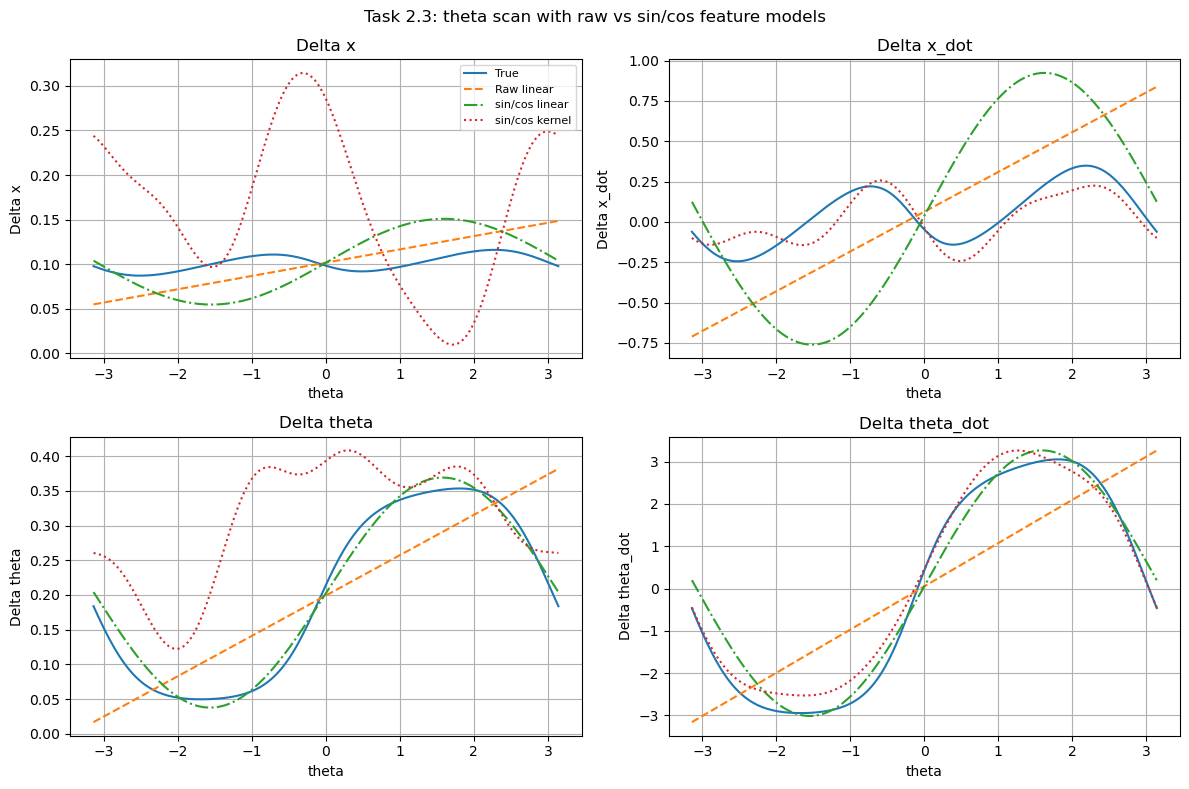

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for dim in range(4):
    ax = axes[dim]

    ax.plot(theta_scan, Delta_true_scan[:, dim], label="True")
    ax.plot(theta_scan, Delta_raw_linear_scan[:, dim], linestyle="--", label="Raw linear")
    ax.plot(theta_scan, Delta_sincos_linear_scan[:, dim], linestyle="-.", label="sin/cos linear")
    ax.plot(theta_scan, Delta_sincos_kernel_scan[:, dim], linestyle=":", label="sin/cos kernel")

    ax.set_xlabel("theta")
    ax.set_ylabel(DELTA_NAMES[dim])
    ax.set_title(DELTA_NAMES[dim])
    ax.grid(True)

    if dim == 0:
        ax.legend(fontsize=8)

fig.suptitle("Task 2.3: theta scan with raw vs sin/cos feature models")
fig.tight_layout()

save_figure(fig, "sf3_task2_3_theta_scan_model_comparison.png")
plt.show()

In [38]:
def rollout_true_zero_force(initial_state, num_steps):
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = system.getState()

    for step in range(num_steps):
        system.performAction(0.0)
        trajectory[step + 1] = system.getState()

    return trajectory


def rollout_sincos_kernel_model(
    initial_state,
    num_steps,
    centres_sincos,
    length_scales_sincos,
    alpha_sincos,
):
    """
    Model rollout without angle remapping.

    The raw theta is allowed to evolve continuously.
    The feature transform uses sin(theta), cos(theta), so periodicity is handled by representation.
    """
    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = np.asarray(initial_state, dtype=float)

    for step in range(num_steps):
        current_state = trajectory[step]

        z = make_sincos_state_features(current_state)

        delta_pred = predict_kernel_model_features(
            z,
            centres_sincos,
            length_scales_sincos,
            alpha_sincos,
        )[0]

        next_state = current_state + delta_pred

        # No remap here.
        trajectory[step + 1] = next_state

    return trajectory

In [40]:
initial_state_rollout = np.array([0.0, 0.0, np.pi, 8.0])
num_steps_rollout = 80

true_traj = rollout_true_zero_force(
    initial_state_rollout,
    num_steps_rollout,
)

sincos_kernel_traj = rollout_sincos_kernel_model(
    initial_state_rollout,
    num_steps_rollout,
    centres_sincos,
    length_scales_sincos,
    alpha_sincos,
)

print("true_traj shape:", true_traj.shape)
print("sincos_kernel_traj shape:", sincos_kernel_traj.shape)

print("true theta raw range:", true_traj[:, 2].min(), true_traj[:, 2].max())
print("model theta raw range:", sincos_kernel_traj[:, 2].min(), sincos_kernel_traj[:, 2].max())

true_traj shape: (81, 4)
sincos_kernel_traj shape: (81, 4)
true theta raw range: 1.9363435740659203 4.377220499018058
model theta raw range: 1.93739995748139 4.575340430640747


In [42]:
def remap_angle_array(theta_values):
    return np.array([remap_angle(theta) for theta in theta_values])


def remap_trajectory_angle_for_plot(trajectory):
    trajectory_plot = trajectory.copy()
    trajectory_plot[:, 2] = remap_angle_array(trajectory_plot[:, 2])
    return trajectory_plot


def plot_rollout_comparison(true_traj, model_traj, filename, title, first_n_steps=None):
    true_plot = remap_trajectory_angle_for_plot(true_traj)
    model_plot = remap_trajectory_angle_for_plot(model_traj)

    if first_n_steps is not None:
        true_plot = true_plot[:first_n_steps + 1]
        model_plot = model_plot[:first_n_steps + 1]
        time = np.arange(first_n_steps + 1)
    else:
        time = np.arange(true_plot.shape[0])

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()

    for dim in range(4):
        ax = axes[dim]

        ax.plot(time, true_plot[:, dim], label="True")
        ax.plot(time, model_plot[:, dim], linestyle="--", label="sin/cos kernel")

        ax.set_xlabel("Time step")
        ax.set_ylabel(STATE_LABELS[dim])
        ax.set_title(RAW_STATE_NAMES[dim])
        ax.grid(True)
        ax.legend()

    fig.suptitle(title)
    fig.tight_layout()

    save_figure(fig, filename)
    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_3_sincos_kernel_rollout_comparison.png


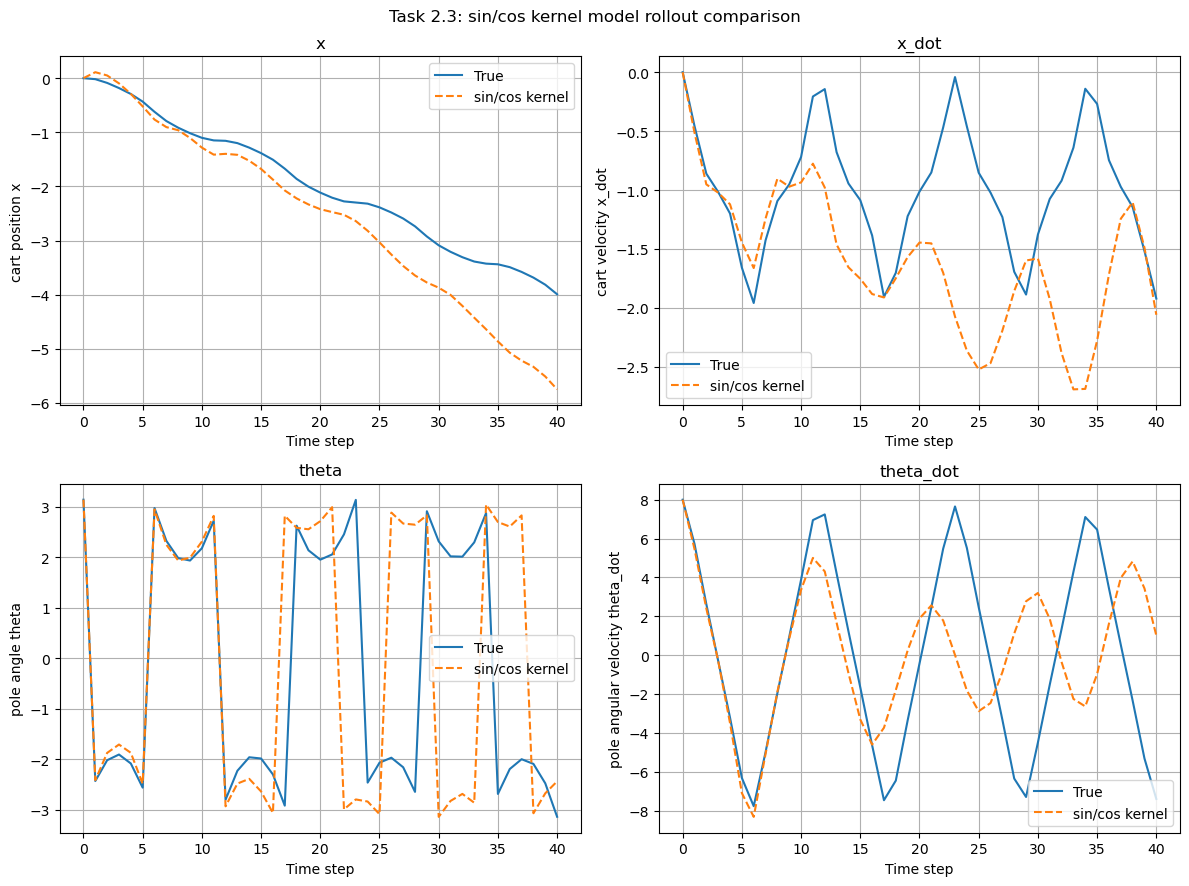

In [44]:
plot_rollout_comparison(
    true_traj=true_traj,
    model_traj=sincos_kernel_traj,
    filename="sf3_task2_3_sincos_kernel_rollout_comparison.png",
    title="Task 2.3: sin/cos kernel model rollout comparison",
    first_n_steps=40,
)

Rollout error after 10 steps: 0.6081451968310333
Rollout error after 20 steps: 2.5006053575897447
Final rollout error: 4.230597378299707
Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_3_sincos_kernel_rollout_error.png


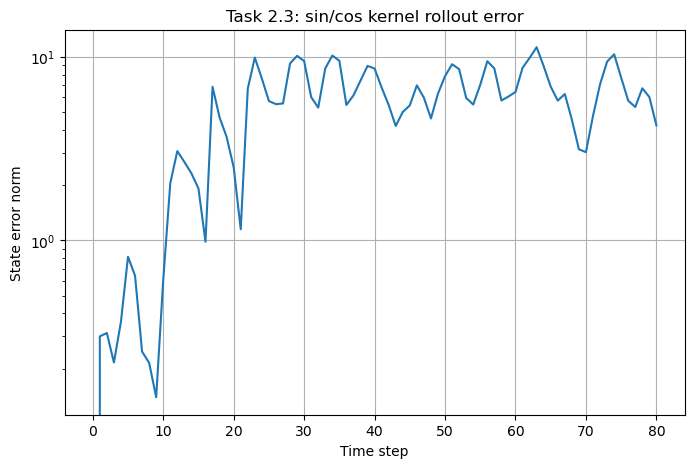

In [46]:
true_plot = remap_trajectory_angle_for_plot(true_traj)
model_plot = remap_trajectory_angle_for_plot(sincos_kernel_traj)

rollout_error = model_plot - true_plot
rollout_error_norm = np.linalg.norm(rollout_error, axis=1)

print("Rollout error after 10 steps:", rollout_error_norm[10])
print("Rollout error after 20 steps:", rollout_error_norm[20])
print("Final rollout error:", rollout_error_norm[-1])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.arange(num_steps_rollout + 1), rollout_error_norm)

ax.set_xlabel("Time step")
ax.set_ylabel("State error norm")
ax.set_title("Task 2.3: sin/cos kernel rollout error")
ax.set_yscale("log")
ax.grid(True)

save_figure(fig, "sf3_task2_3_sincos_kernel_rollout_error.png")
plt.show()

In [48]:
model_path = DATA_DIR / "task2_3_sincos_kernel_model.npz"

np.savez(
    model_path,
    centres_sincos=centres_sincos,
    length_scales_sincos=length_scales_sincos,
    alpha_sincos=alpha_sincos,
    reg_strength=reg_strength,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    M=M,
)

print("Saved sin/cos kernel model to:", model_path)

Saved sin/cos kernel model to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task2_3_sincos_kernel_model.npz
